In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


In [ ]:
!pip install pyngrok

In [ ]:
conn = sqlite3.connect("students.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS students (
    student_id INTEGER PRIMARY KEY,
    study_hours REAL,
    attendance REAL,
    final_marks REAL,
    predicted_marks REAL
)
""")

cursor.execute("DELETE FROM students")

data = [
    (1, 2, 60, 50, None),
    (2, 4, 70, 60, None),
    (3, 6, 80, 70, None),
    (4, 8, 90, 85, None),
    (5, 10, 95, 92, None),
]

cursor.executemany(
    "INSERT INTO students VALUES (?, ?, ?, ?, ?)", data
)

conn.commit()
conn.close()

print("Database created and data inserted")


Database created and data inserted


In [ ]:
conn = sqlite3.connect("students.db")

df = pd.read_sql_query("SELECT * FROM students", conn)
conn.close()

df


,student_id,study_hours,attendance,final_marks,predicted_marks
0,1,2.0,60.0,50.0,None
1,2,4.0,70.0,60.0,None
2,3,6.0,80.0,70.0,None
3,4,8.0,90.0,85.0,None
4,5,10.0,95.0,92.0,None


In [ ]:
X = df[['study_hours', 'attendance']]
y = df['final_marks']

model = LinearRegression()
model.fit(X, y)

df['predicted_marks'] = model.predict(X)

df


,student_id,study_hours,attendance,final_marks,predicted_marks
0,1,2.0,60.0,50.0,49.0
1,2,4.0,70.0,60.0,60.5
2,3,6.0,80.0,70.0,72.0
3,4,8.0,90.0,85.0,83.5
4,5,10.0,95.0,92.0,92.0


In [ ]:
conn = sqlite3.connect("students.db")
cursor = conn.cursor()

for _, row in df.iterrows():
    cursor.execute("""
        UPDATE students
        SET predicted_marks = ?
        WHERE student_id = ?
    """, (row['predicted_marks'], row['student_id']))

conn.commit()
conn.close()

print("Predictions stored in database")


Predictions stored in database


In [ ]:
r2 = r2_score(df['final_marks'], df['predicted_marks'])
mae = mean_absolute_error(df['final_marks'], df['predicted_marks'])

print("R² Score:", r2)
print("Mean Absolute Error:", mae)


R² Score: 0.9937458305537025
Mean Absolute Error: 1.0000000000000029


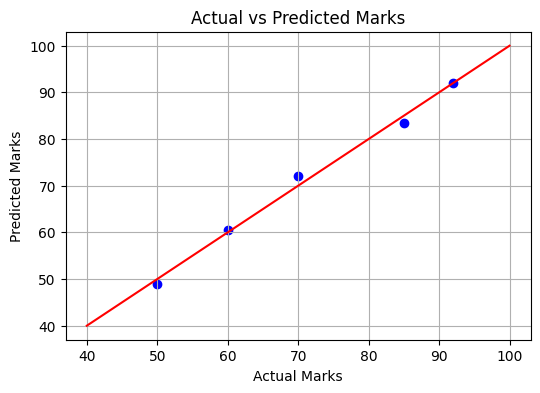

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df['final_marks'], df['predicted_marks'], color='blue')
plt.plot([40, 100], [40, 100], color='red')

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.grid(True)

plt.show()


In [ ]:
from flask import Flask

app = Flask(__name__)

@app.route("/")
def home():
    return "Flask app is running!"

app.run(port=5000)


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
